### Loading Saved Model

In [1]:
import tensorflow as tf

MODEL_PATH = r"D:\Project v2\saved_models\mobilenetv2_global_final_tuned.keras"
model = tf.keras.models.load_model(MODEL_PATH)

print("Model loaded")


Model loaded


### Setting TEST directory

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

TEST_DIR = r"D:\Project v2\datasets\global_dataset\test"

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

print("Class indices:", test_gen.class_indices)

Found 11997 images belonging to 2 classes.
Class indices: {'fake': 0, 'real': 1}


### Model Evaluation

In [3]:
loss, acc = model.evaluate(test_gen)
print("Test Accuracy:", acc)

d:\Project v2\.venv\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


375/375 ━━━━━━━━━━━━━━━━━━━━ 3359s 9s/step - accuracy: 0.9170 - loss: 0.2095
Test Accuracy: 0.87563556432724


### Confusion Matrix

In [4]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

y_prob = model.predict(test_gen)
y_pred = (y_prob > 0.5).astype(int).ravel()
y_true = test_gen.classes

375/375 ━━━━━━━━━━━━━━━━━━━━ 1993s 5s/step


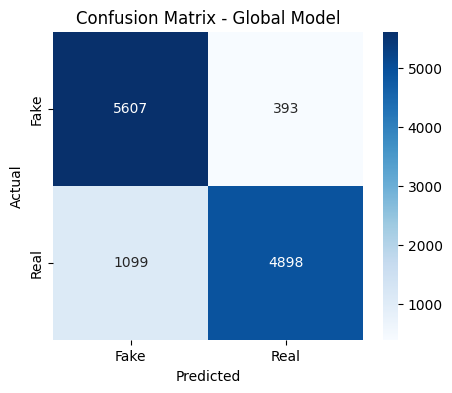

In [5]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake","Real"],
    yticklabels=["Fake","Real"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Global Model")
plt.show()

### Classification Report

In [6]:
print(classification_report(
    y_true,
    y_pred,
    target_names=["Fake","Real"]
))

              precision    recall  f1-score   support

        Fake       0.84      0.93      0.88      6000
        Real       0.93      0.82      0.87      5997

    accuracy                           0.88     11997
   macro avg       0.88      0.88      0.88     11997
weighted avg       0.88      0.88      0.88     11997



### Random Images Test

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [3]:
TEST_DIR = r"D:\Project v2\datasets\global_dataset\test"

In [4]:
def get_two_random_images(test_dir):
    samples = []
    classes = ["fake", "real"]

    for label in classes:
        class_path = os.path.join(test_dir, label)
        img_name = random.choice(os.listdir(class_path))
        img_path = os.path.join(class_path, img_name)
        samples.append((img_path, label))

    return samples

In [5]:
def predict_image(img_path, model):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    prob = model.predict(img_array, verbose=0)[0][0]
    pred_label = "Real" if prob > 0.5 else "Fake"

    return pred_label, prob, img

In [6]:
def show_two_random_predictions(model, test_dir):
    samples = get_two_random_images(test_dir)

    plt.figure(figsize=(8,4))

    for i, (img_path, true_label) in enumerate(samples):
        pred_label, prob, img = predict_image(img_path, model)

        plt.subplot(1, 2, i+1)
        plt.imshow(img)
        plt.axis("off")

        color = "green" if pred_label == "Real" else "red"

        plt.title(
            f"True: {true_label.upper()}\nPred: {pred_label} ({prob:.2f})",
            color=color
        )

    plt.tight_layout()
    plt.show()

## Random Test Runner (Run below cell)

### Execution Flow
- 'Load Saved Model' Cell -> Each Cell From 'Random Images Test'

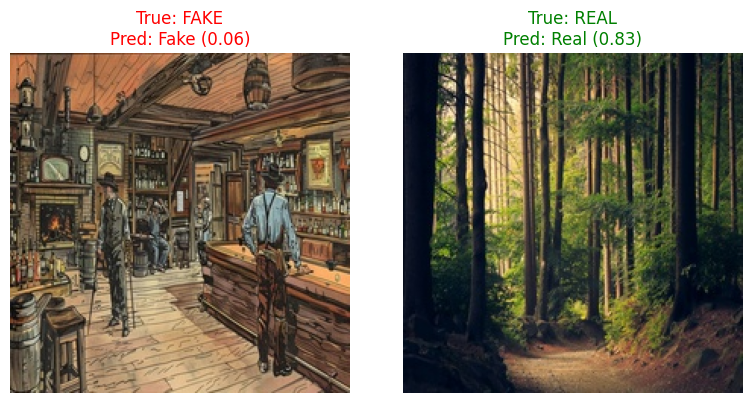

In [8]:
show_two_random_predictions(model, TEST_DIR)